# 01 — Разведочный анализ

**Задача:** Предсказание банкротства компаний  
**Данные:** American Companies Bankruptcy Prediction Dataset (Kaggle)  
**Источник:** NYSE / NASDAQ, финансовая отчётность 1999–2018 гг.  
**Целевая переменная:** `status_label` → `bankrupt` (1 = обанкротилась, 0 = работает)

## 0. Настройка окружения

In [ ]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import (
    load_raw_data,
    encode_target,
    drop_duplicates,
    handle_missing,
    RAW_FEATURES,
    TARGET,
    TARGET_BIN,
)

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 30)
SEED = 42

## 1. Загрузка данных

In [2]:
raw = load_raw_data("../data/raw/american_bankruptcy.csv")
print(f"Размер датасета: {raw.shape[0]:,} строк × {raw.shape[1]} столбцов")
print(f"Период: {raw['year'].min()} – {raw['year'].max()}")
print(f"Уникальных компаний: {raw['company_name'].nunique():,}")
raw.head(5)

Размер датасета: 78,682 строк × 21 столбцов
Период: 1999 – 2018
Уникальных компаний: 8,971


,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,372.7519,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,377.1180,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,364.5928,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,143.3295,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,308.9071,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [3]:
df = encode_target(raw)
df = drop_duplicates(df)
df = handle_missing(df)
print(f"После очистки: {df.shape[0]:,} строк")

Удалено дубликатов: 0
Нет пропусков
После очистки: 78,682 строк


## 2. Целевая переменная

In [4]:
counts = df[TARGET].value_counts()
bankrupt_rate = df[TARGET_BIN].mean() * 100

print("Распределение классов:")
print(counts.to_string())
print(f"\nДоля банкротств: {bankrupt_rate:.2f}%")

Распределение классов:
status_label
alive     73462
failed     5220

Доля банкротств: 6.63%


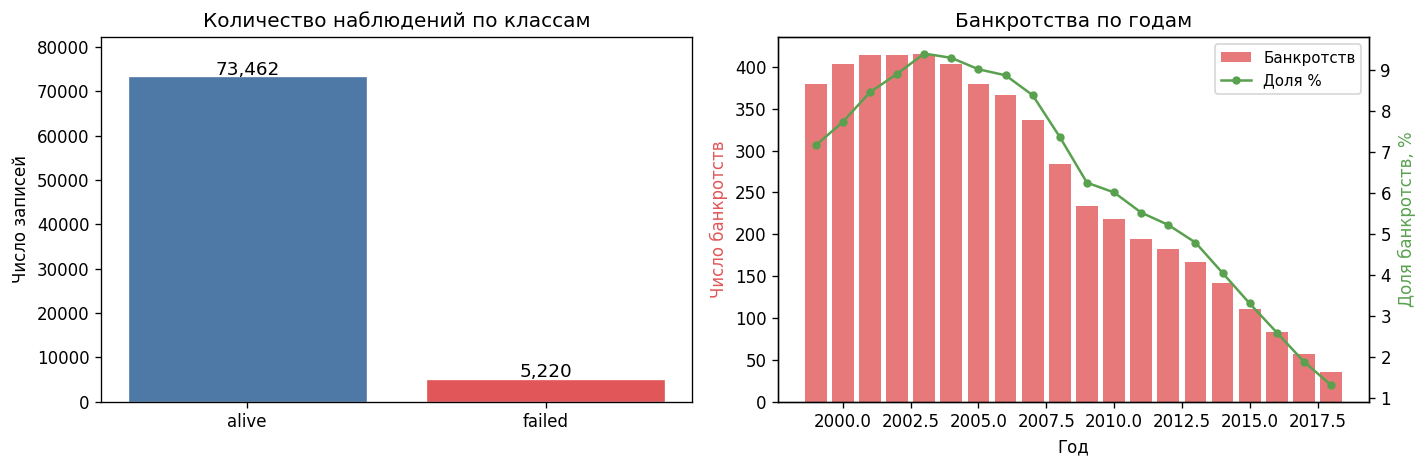


Пик банкротств: 2003 (415 компаний)
Максимальная доля банкротств: 9.4% (2003)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart классов
colors = ["#4e79a7", "#e15759"]
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.8)
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 300, f"{val:,}", ha="center", fontsize=11)
axes[0].set_title("Количество наблюдений по классам", fontsize=12)
axes[0].set_ylabel("Число записей")
axes[0].set_ylim(0, counts.max() * 1.12)

# Динамика банкротств по годам
yearly = df.groupby("year")[TARGET_BIN].agg(["sum", "count"])
yearly["rate"] = yearly["sum"] / yearly["count"] * 100
axes[1].bar(yearly.index, yearly["sum"], color="#e15759", alpha=0.8, label="Банкротств")
ax2 = axes[1].twinx()
ax2.plot(yearly.index, yearly["rate"], color="#59a14f", marker="o", markersize=4, label="Доля %")
axes[1].set_title("Банкротства по годам", fontsize=12)
axes[1].set_xlabel("Год")
axes[1].set_ylabel("Число банкротств", color="#e15759")
ax2.set_ylabel("Доля банкротств, %", color="#59a14f")

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.savefig("../report/images/eda_target.png", bbox_inches="tight")
plt.show()

print(f"\nПик банкротств: {yearly['sum'].idxmax()} ({yearly['sum'].max()} компаний)")
print(f"Максимальная доля банкротств: {yearly['rate'].max():.1f}% ({yearly['rate'].idxmax()})")

## 3. Общая статистика по признакам

In [6]:
df[RAW_FEATURES].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
X1,78682.0,880.362,3928.565,-7.760,18.924,100.450,431.527,169662.00
X2,78682.0,1594.529,8930.485,-366.645,17.038,103.661,634.548,374623.00
X3,78682.0,121.234,652.377,0.000,1.192,7.930,47.972,28430.00
X4,78682.0,376.759,2012.023,-21913.000,-0.811,15.035,139.655,81730.00
X5,78682.0,201.606,1060.766,0.000,0.000,7.023,74.747,62567.00
X6,78682.0,129.382,1265.532,-98696.000,-7.416,1.616,40.144,104821.00
X7,78682.0,286.833,1335.979,-0.006,3.281,22.820,131.580,65812.00
X8,78682.0,3414.355,18414.104,0.000,34.980,227.512,1244.890,1073390.54
X9,78682.0,2364.020,11950.069,-1964.999,27.548,186.598,1046.402,511729.00
X10,78682.0,2867.111,12917.944,0.001,37.364,213.204,1171.365,531864.00


In [7]:
missing = df[RAW_FEATURES].isnull().sum()
print(f"Столбцов с пропусками: {(missing > 0).sum()}")
if missing.sum() > 0:
    print(missing[missing > 0])

Столбцов с пропусками: 0


## 4. Распределения признаков

In [8]:
# Описание признаков (из документации Kaggle)
FEATURE_DESC = {
    "X1":  "Working Capital / Total Assets",
    "X2":  "Retained Earnings / Total Assets",
    "X3":  "EBIT / Total Assets",
    "X4":  "Book Value of Equity / Total Liabilities",
    "X5":  "Revenue / Total Assets",
    "X6":  "Net Income / Total Assets",
    "X7":  "Total Debt / Total Assets",
    "X8":  "Current Ratio",
    "X9":  "Total Assets",
    "X10": "Revenue",
    "X11": "Gross Profit",
    "X12": "EBITDA",
    "X13": "Net Profit Margin",
    "X14": "Operating Cash Flow",
    "X15": "CapEx",
    "X16": "Total Equity",
    "X17": "Long-term Debt",
    "X18": "Operating Income",
}

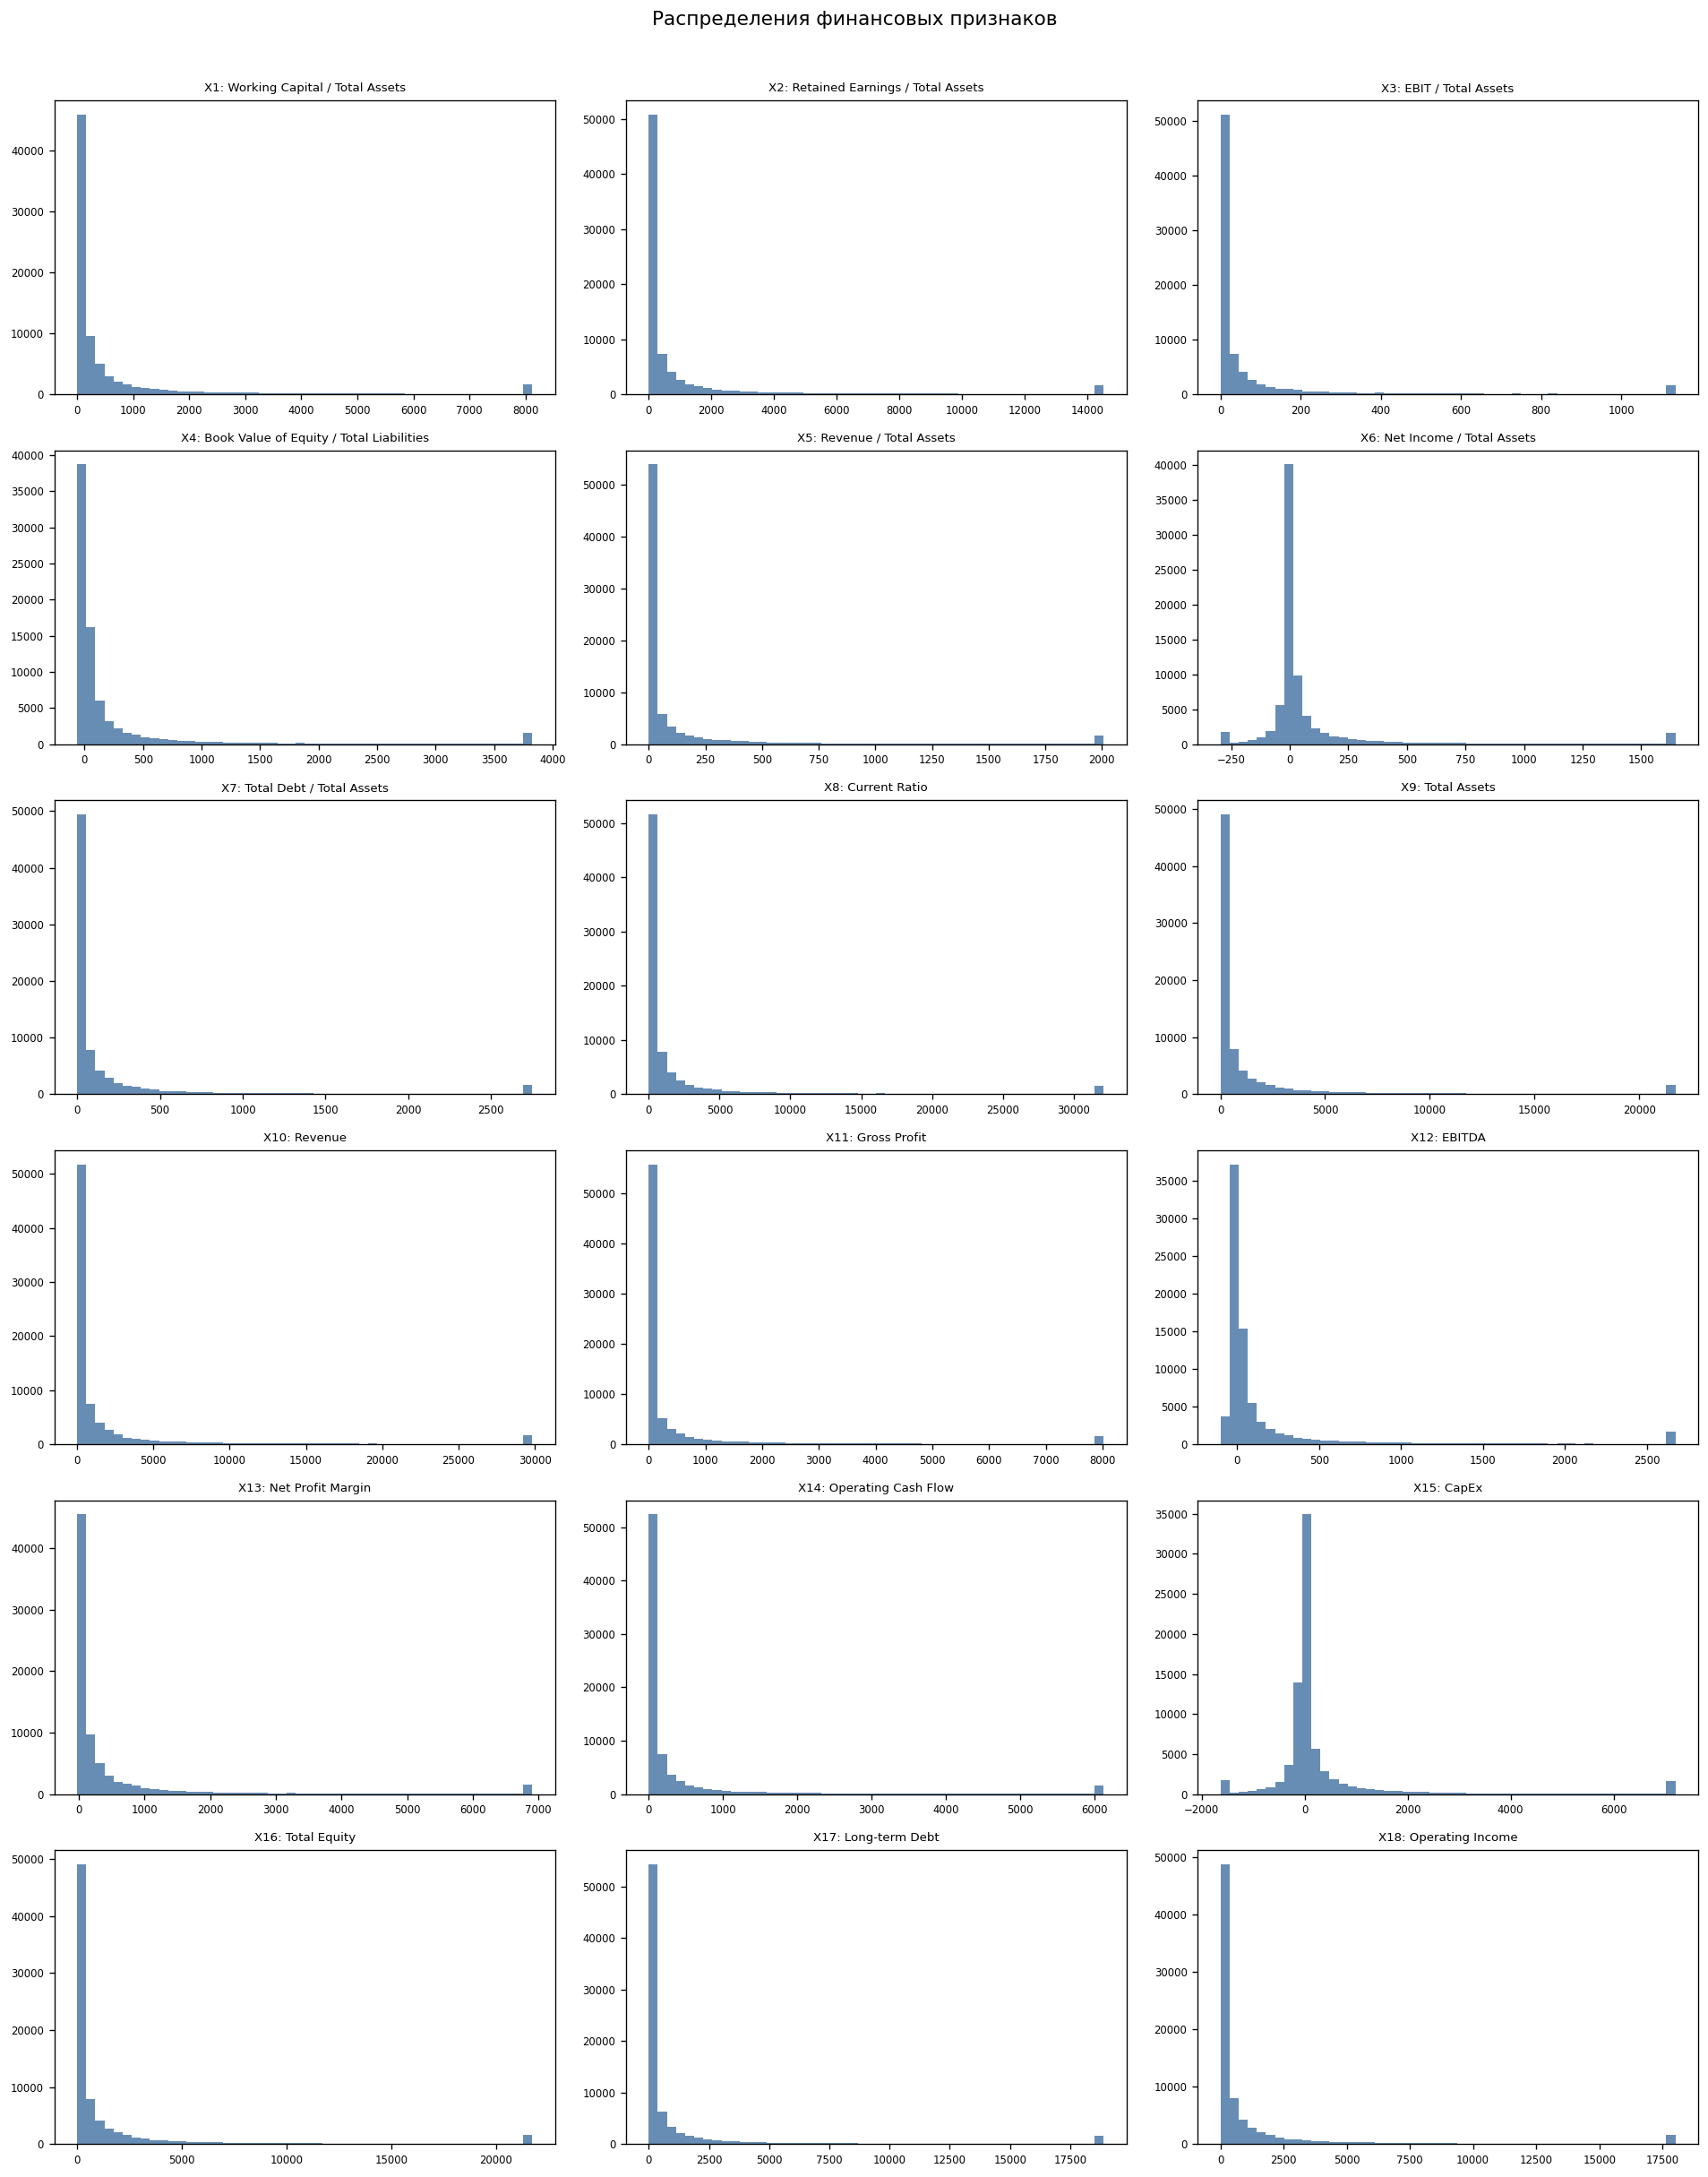

In [9]:
fig, axes = plt.subplots(6, 3, figsize=(16, 20))
axes = axes.flatten()

for i, feat in enumerate(RAW_FEATURES):
    ax = axes[i]

    vals = df[feat].clip(
        df[feat].quantile(0.02),
        df[feat].quantile(0.98),
    )
    ax.hist(vals, bins=50, color="#4e79a7", edgecolor="none", alpha=0.85)
    ax.set_title(f"{feat}: {FEATURE_DESC.get(feat, '')}", fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle("Распределения финансовых признаков", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../report/images/eda_feature_distributions.png", bbox_inches="tight")
plt.show()

## 5. Признаки по классам

In [10]:
# Сравниваем медианы обанкротившихся и необонкротившихся компаний
median_by_class = df.groupby(TARGET_BIN)[RAW_FEATURES].median()
median_by_class.index = ["Не банкрот (0)", "Банкрот (1)"]
median_by_class.T.round(3)

,Не банкрот (0),Банкрот (1)
X1,102.917,75.872
X2,103.534,106.638
X3,7.935,7.847
X4,15.618,7.790
X5,7.117,6.171
X6,2.072,-3.327
X7,23.454,15.218
X8,240.895,117.799
X9,187.070,180.834
X10,215.006,195.137


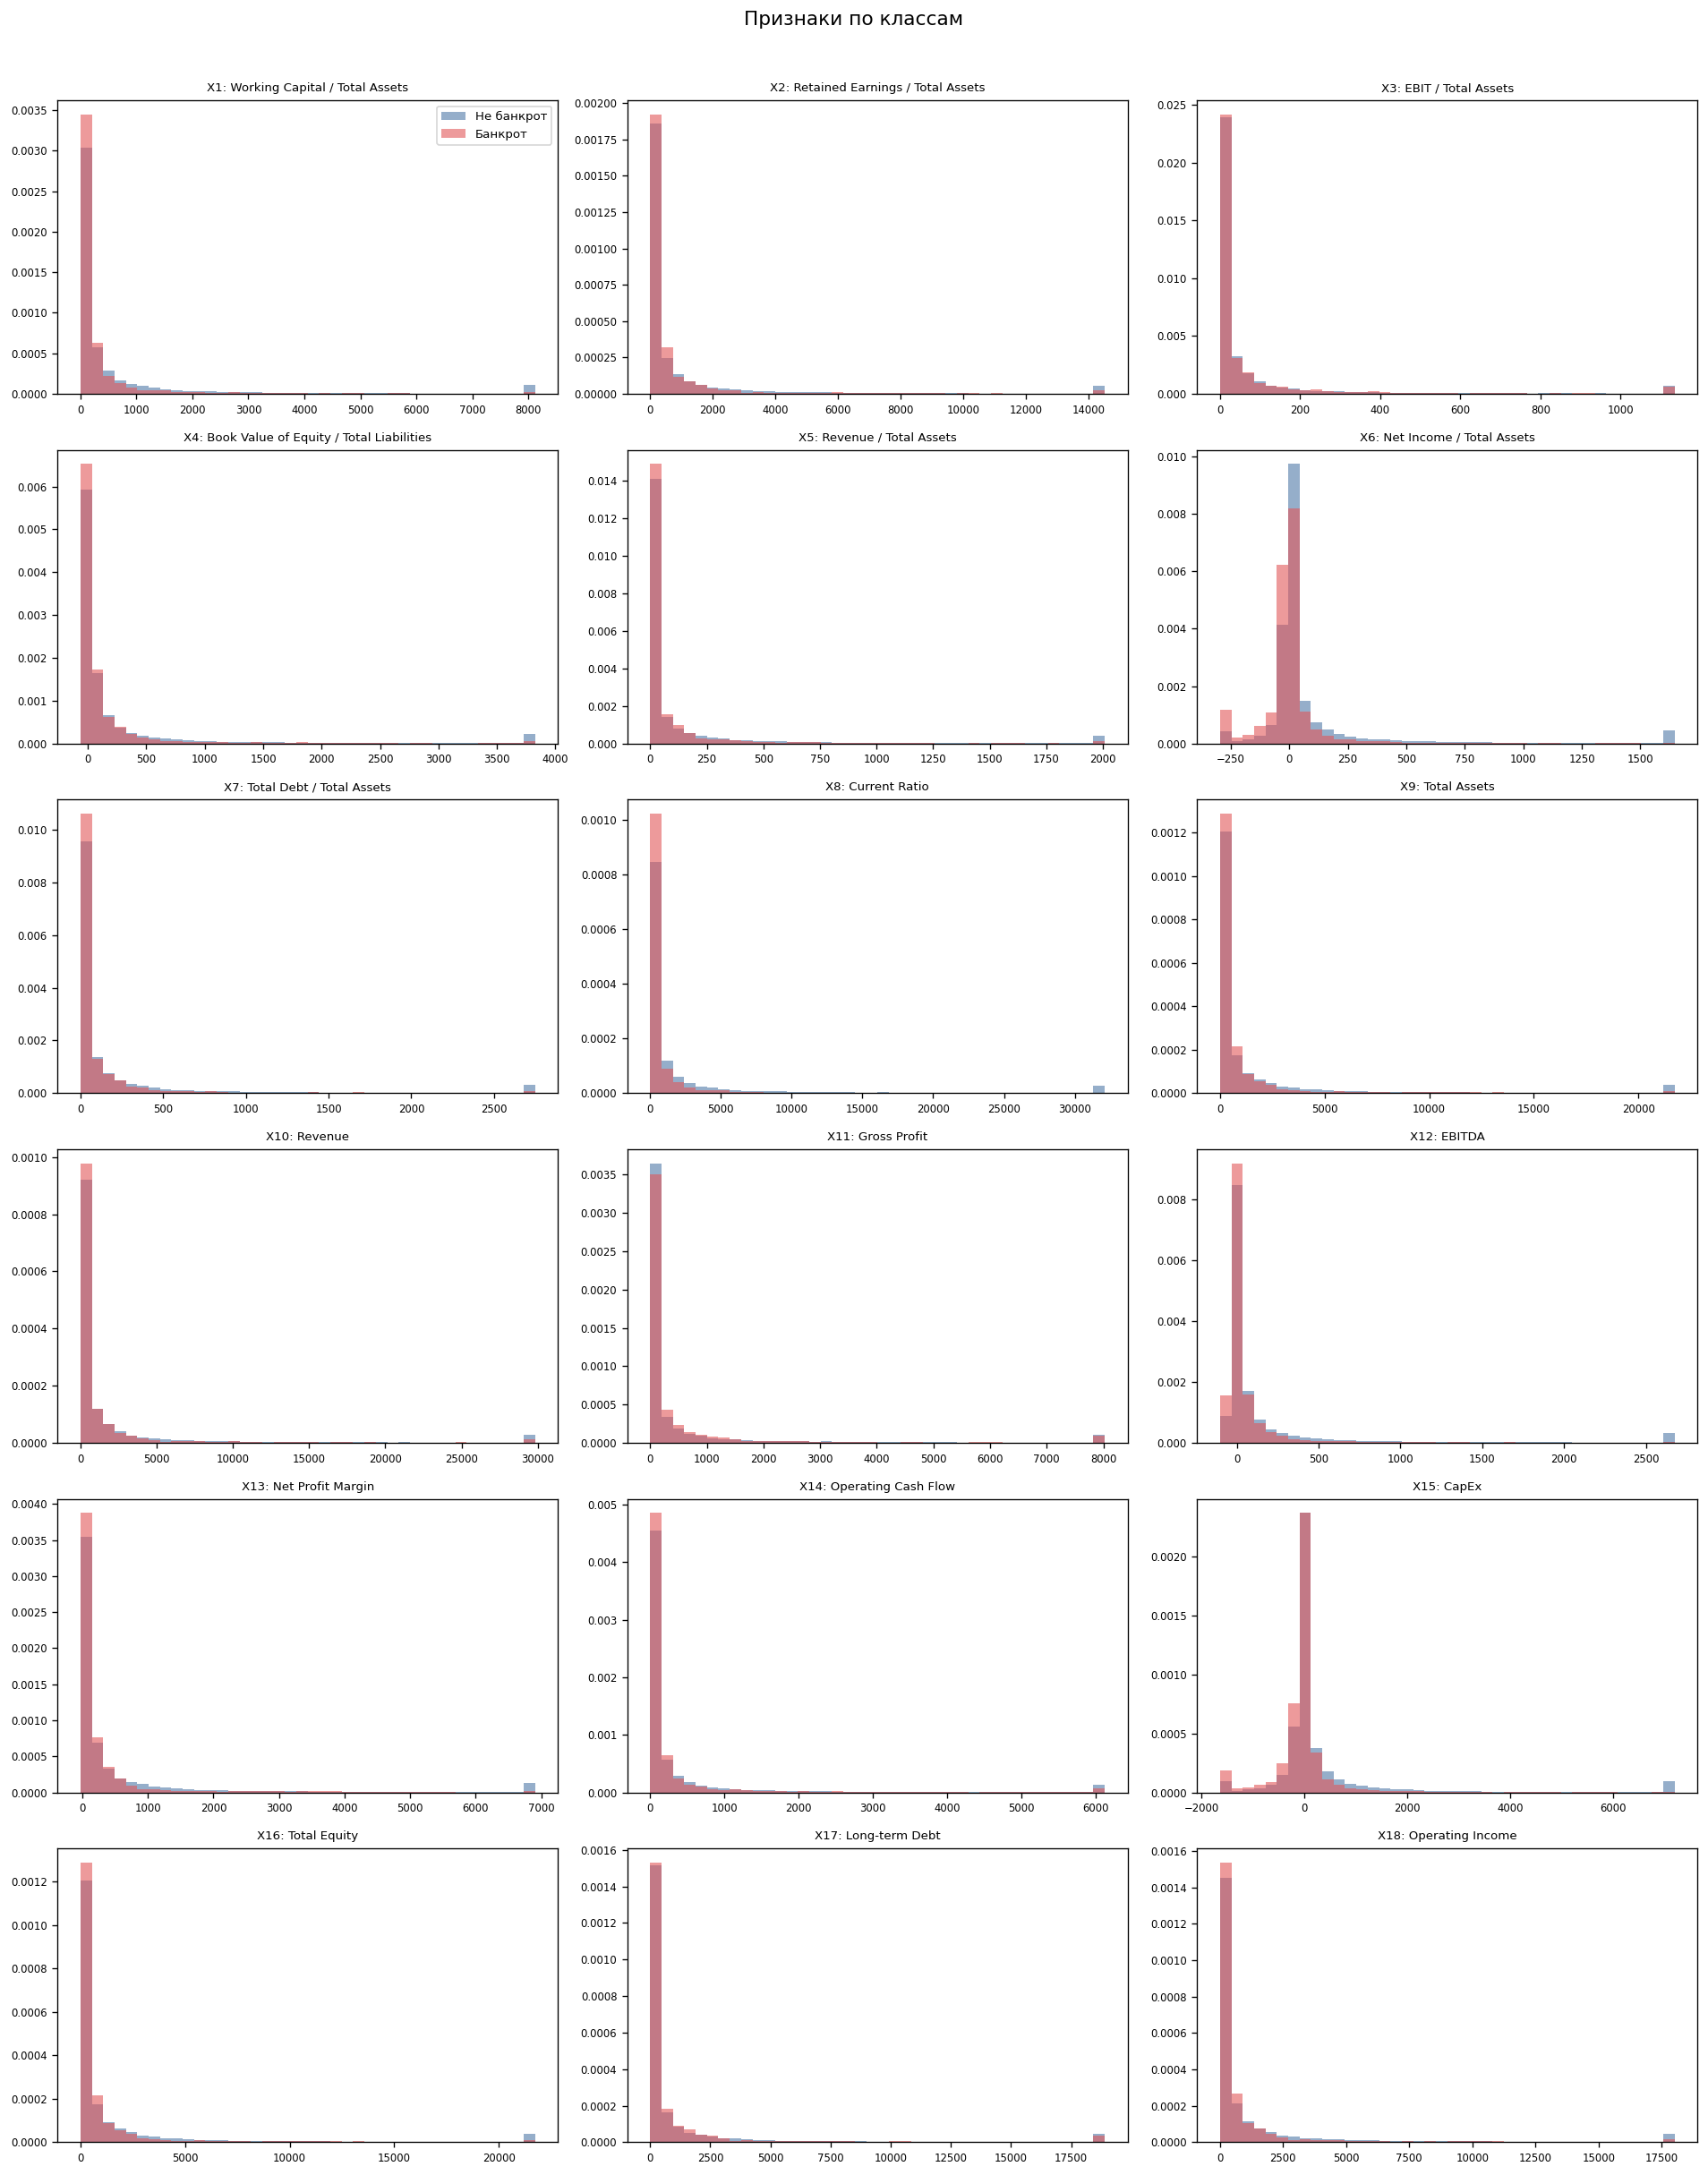

In [11]:
fig, axes = plt.subplots(6, 3, figsize=(16, 20))
axes = axes.flatten()

palette = {0: "#4e79a7", 1: "#e15759"}
labels_map = {0: "Не банкрот", 1: "Банкрот"}

for i, feat in enumerate(RAW_FEATURES):
    ax = axes[i]
    lo = df[feat].quantile(0.02)
    hi = df[feat].quantile(0.98)
    for cls in [0, 1]:
        vals = df.loc[df[TARGET_BIN] == cls, feat].clip(lo, hi)
        ax.hist(
            vals, bins=40, alpha=0.6,
            color=palette[cls], label=labels_map[cls],
            edgecolor="none", density=True,
        )
    ax.set_title(f"{feat}: {FEATURE_DESC.get(feat, '')}", fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("Признаки по классам", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../report/images/eda_class_distributions.png", bbox_inches="tight")
plt.show()

## 6. Выбросы

In [12]:
outlier_stats = []
for feat in RAW_FEATURES:
    q1, q3 = df[feat].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    n_out = ((df[feat] < lo) | (df[feat] > hi)).sum()
    outlier_stats.append({"Показатель": feat, "Количество выбросов": n_out, "Доля": n_out / len(df) * 100})

outlier_df = pd.DataFrame(outlier_stats).sort_values("Доля", ascending=False)
print("Топ-10 признаков по количеству выбросов:")
print(outlier_df.head(10).to_string(index=False))

Топ-10 признаков по количеству выбросов:
Показатель  Количество выбросов      Доля
       X15                12455 15.829542
        X6                11876 15.093668
       X11                 9592 12.190844
       X12                 9434 11.990036
       X17                 9273 11.785415
        X5                 9215 11.711700
        X4                 8784 11.163926
       X14                 8738 11.105462
       X10                 8412 10.691136
        X3                 8267 10.506850


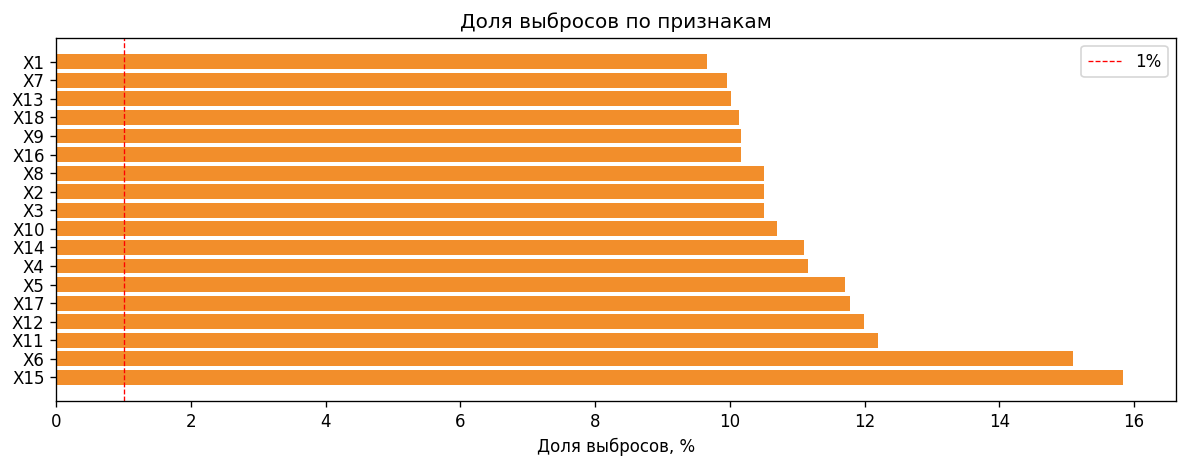

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(outlier_df["Показатель"], outlier_df["Доля"], color="#f28e2b", edgecolor="none")
ax.set_xlabel("Доля выбросов, %")
ax.set_title("Доля выбросов по признакам")
ax.axvline(1.0, color="red", linestyle="--", linewidth=0.8, label="1%")
ax.legend()
plt.tight_layout()
plt.savefig("../report/images/eda_outliers.png", bbox_inches="tight")
plt.show()


## 7. Матрица корреляций

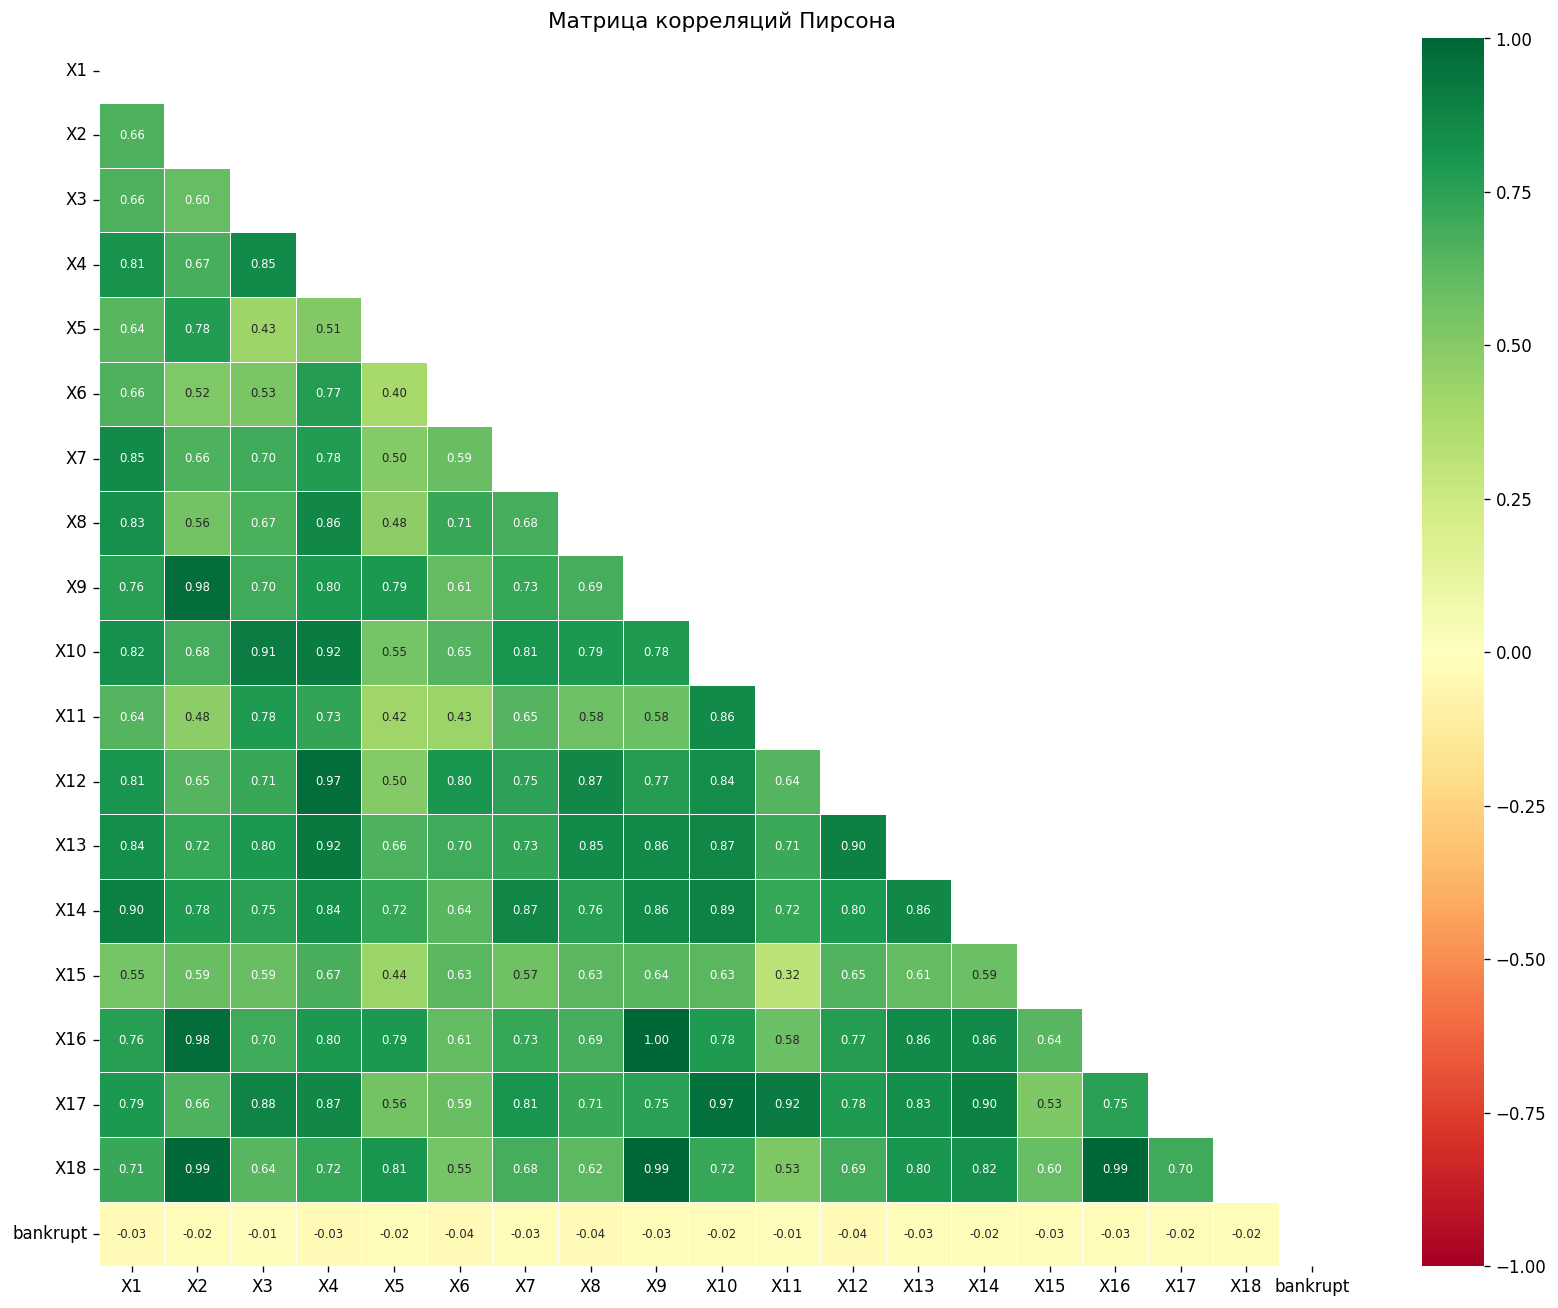

In [14]:
corr = df[RAW_FEATURES + [TARGET_BIN]].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, annot_kws={"size": 7},
)
ax.set_title("Матрица корреляций Пирсона", fontsize=13)
plt.tight_layout()
plt.savefig("../report/images/eda_correlation.png", bbox_inches="tight")
plt.show()

In [15]:
target_corr = corr[TARGET_BIN].drop(TARGET_BIN).sort_values(key=abs, ascending=False)
print("Корреляция признаков с bankrupt:")
print(target_corr.round(4).to_string())

Корреляция признаков с bankrupt:
X6    -0.0374
X8    -0.0370
X12   -0.0362
X1    -0.0326
X4    -0.0316
X13   -0.0312
X7    -0.0308
X15   -0.0292
X16   -0.0263
X9    -0.0263
X10   -0.0248
X5    -0.0246
X18   -0.0241
X14   -0.0238
X2    -0.0220
X17   -0.0168
X3    -0.0144
X11   -0.0093


## 8. Временная динамика ключевых признаков

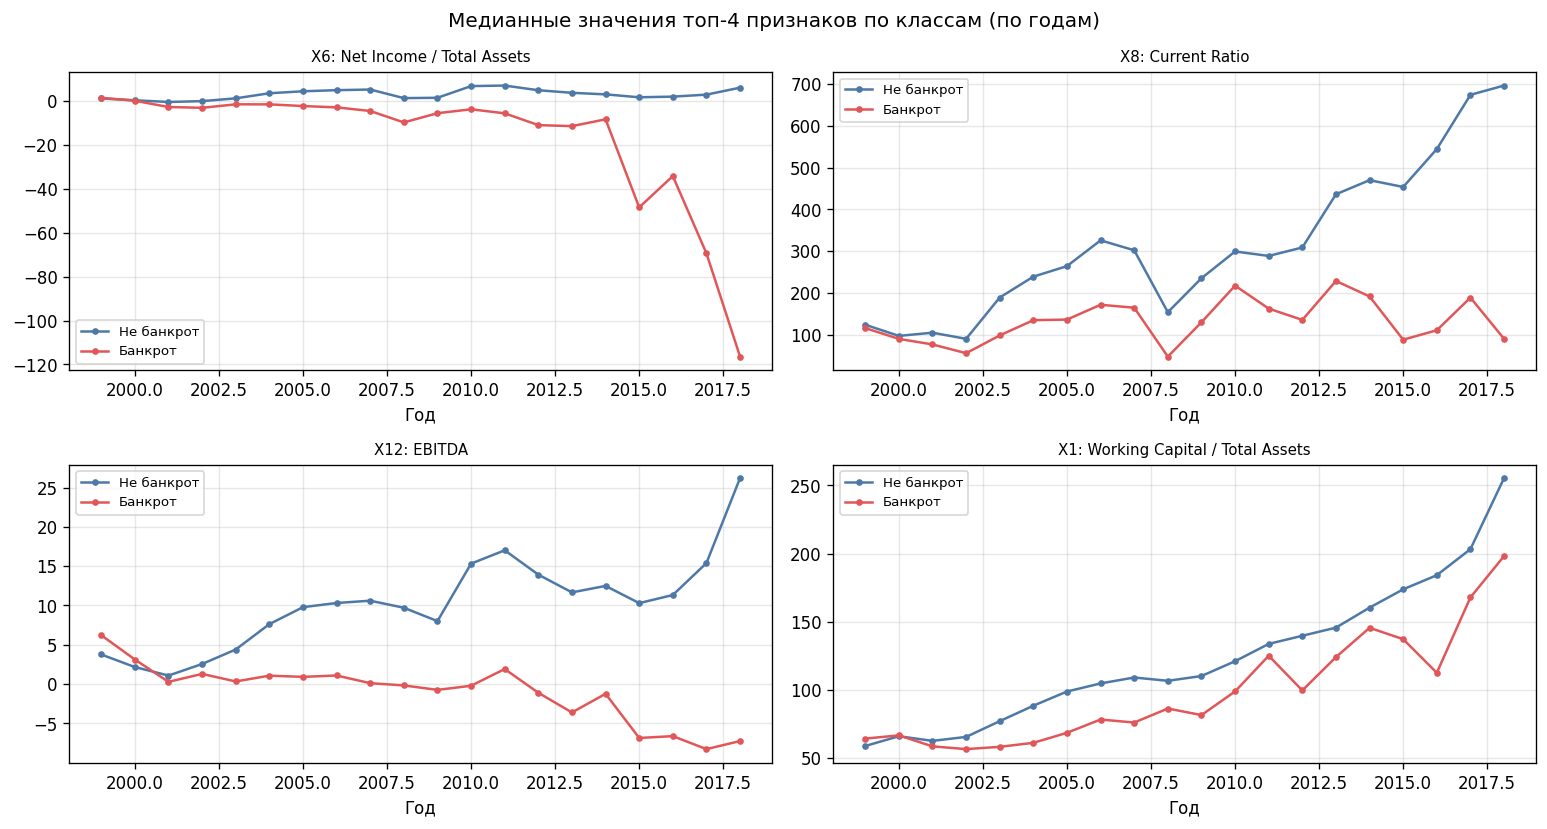

In [16]:
top_feats = target_corr.abs().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    ax = axes[i]
    yearly_med = df.groupby(["year", TARGET_BIN])[feat].median().reset_index()
    for cls, color, label in [(0, "#4e79a7", "Не банкрот"), (1, "#e15759", "Банкрот")]:
        sub = yearly_med[yearly_med[TARGET_BIN] == cls]
        ax.plot(sub["year"], sub[feat], marker="o", markersize=3,
                color=color, label=label, linewidth=1.5)
    ax.set_title(f"{feat}: {FEATURE_DESC.get(feat, '')}", fontsize=9)
    ax.set_xlabel("Год")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Медианные значения топ-4 признаков по классам (по годам)", fontsize=12)
plt.tight_layout()
plt.savefig("../report/images/eda_temporal.png", bbox_inches="tight")
plt.show()